In [1]:
import intake
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 8})
import warnings
warnings.filterwarnings("ignore") # Suppress warnings for these docs
from os import environ
environ["PYTHONWARNINGS"] = "ignore"
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import glob
import cmocean.cm as cmocean
import xgcm
import logging
#import cosima_cookbook as cc
from xgcm import Grid
import gcm_filters
import cartopy.crs as ccrs                        # For making maps.
import matplotlib.path as mpath
import cartopy.feature as cft                     # For adding features to maps
%matplotlib inline
%config InlineBackend.figure_format='retina'
from glob import glob
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors

plt.rcParams["mathtext.fontset"] = "stix" 

from dask.distributed import Client

client = Client(threads_per_worker=1)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/33445/status,
Dashboard: /proxy/33445/status,Workers: 2
Total threads: 2,Total memory: 9.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:45199,Workers: 0
Dashboard: /proxy/33445/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:33535,Total threads: 1
Dashboard: /proxy/43653/status,Memory: 4.50 GiB
Nanny: tcp://127.0.0.1:34097,


In [3]:
import xarray as xr
import numpy as np

# List of files to check
files = [

    "/scratch/nm03/ee8016/regional_mom6_configs/NW_shelf_iaf_notides_wombatlite_2/hgrid.nc",
    "/scratch/nm03/ee8016/regional_mom6_configs/NW_shelf_iaf_notides_wombatlite_2/vcoord.nc",
    "/scratch/nm03/ee8016/regional_mom6_configs/NW_shelf_iaf_notides_wombatlite_2/bathymetry.nc",
    "/scratch/nm03/ee8016/regional_mom6_configs/NW_shelf_iaf_notides_wombatlite_2/init_tracers_modified.nc",
    #"/scratch/nm03/ee8016/regional_mom6_configs/NW_shelf_iaf_notides_wombatlite_2/obgc_obc.nc",
    "/scratch/nm03/ee8016/regional_mom6_configs/NW_shelf_iaf_notides_wombatlite_2/init_eta.nc",
    "/scratch/nm03/ee8016/regional_mom6_configs/NW_shelf_iaf_notides_wombatlite_2/init_vel.nc",
    "/scratch/nm03/ee8016/regional_mom6_configs/NW_shelf_iaf_notides_wombatlite_2/grid_spec.nc",
    "/scratch/nm03/ee8016/regional_mom6_configs/NW_shelf_iaf_notides_wombatlite_2/land_mask.nc",
    "/scratch/nm03/ee8016/regional_mom6_configs/NW_shelf_iaf_notides_wombatlite_2/ocean_mosaic.nc",
    "/scratch/nm03/ee8016/regional_mom6_configs/NW_shelf_iaf_notides_wombatlite_2/access-rom3-ESMFmesh.nc",
    "/scratch/nm03/ee8016/regional_mom6_configs/NW_shelf_iaf_notides_wombatlite_2/access-rom3-nomask-ESMFmesh.nc",
    "/scratch/nm03/ee8016/regional_mom6_configs/NW_shelf_iaf_notides_wombatlite_2/dust_DS.nc",
]

for f in files:
    try:
        ds = xr.open_dataset(f)
        nan_report = {}
        for v in ds.data_vars:
            arr = ds[v].values
            if np.isnan(arr).any():
                nan_count = np.isnan(arr).sum()
                nan_report[v] = int(nan_count)
        if nan_report:
            print(f"\n⚠️ NaNs found in {f}:")
            for var, count in nan_report.items():
                print(f"   {var}: {count} NaNs")
        else:
            print(f"✅ No NaNs in {f}")
        ds.close()
    except Exception as e:
        print(f"❌ Could not open {f}: {e}")

❌ Could not open /scratch/nm03/ee8016/regional_mom6_configs/NW_shelf_iaf_notides_wombatlite_2/hgrid.nc: ufunc 'isnan' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''
✅ No NaNs in /scratch/nm03/ee8016/regional_mom6_configs/NW_shelf_iaf_notides_wombatlite_2/vcoord.nc

⚠️ NaNs found in /scratch/nm03/ee8016/regional_mom6_configs/NW_shelf_iaf_notides_wombatlite_2/bathymetry.nc:
   depth: 28227 NaNs
✅ No NaNs in /scratch/nm03/ee8016/regional_mom6_configs/NW_shelf_iaf_notides_wombatlite_2/init_tracers_modified.nc
✅ No NaNs in /scratch/nm03/ee8016/regional_mom6_configs/NW_shelf_iaf_notides_wombatlite_2/init_eta.nc
✅ No NaNs in /scratch/nm03/ee8016/regional_mom6_configs/NW_shelf_iaf_notides_wombatlite_2/init_vel.nc
❌ Could not open /scratch/nm03/ee8016/regional_mom6_configs/NW_shelf_iaf_notides_wombatlite_2/grid_spec.nc: ufunc 'isnan' not supported for the input types, and the inputs could not be safely 

In [10]:
nw_hgrid=xr.open_dataset('/scratch/nm03/ee8016/regional_mom6_configs/NW_shelf_iaf_notides_wombatlite/hgrid.nc')
ni_hgrid=xr.open_dataset('/scratch/nm03/ee8016/regional_mom6_configs/Ningaloo_domain_02/hgrid.nc')
nw_vcoord=xr.open_dataset('/scratch/nm03/ee8016/regional_mom6_configs/NW_shelf_iaf_notides_wombatlite/vcoord.nc')
ni_vcoord=xr.open_dataset('/scratch/nm03/ee8016/regional_mom6_configs/Ningaloo_domain_02/vcoord.nc')
nw_eta=xr.open_dataset('/scratch/nm03/ee8016/regional_mom6_configs/NW_shelf_iaf_notides_wombatlite/init_eta.nc')
ni_eta=xr.open_dataset('/scratch/nm03/ee8016/regional_mom6_configs/Ningaloo_domain_02/init_eta.nc')
bathy=xr.open_dataset('/scratch/nm03/ee8016/regional_mom6_configs/Ningaloo_domain_02/bathymetry_mod.nc')
ic=xr.open_dataset('/g/data/nm03/ee8016/Ningaloo_domain/ic_unprocessed.nc')


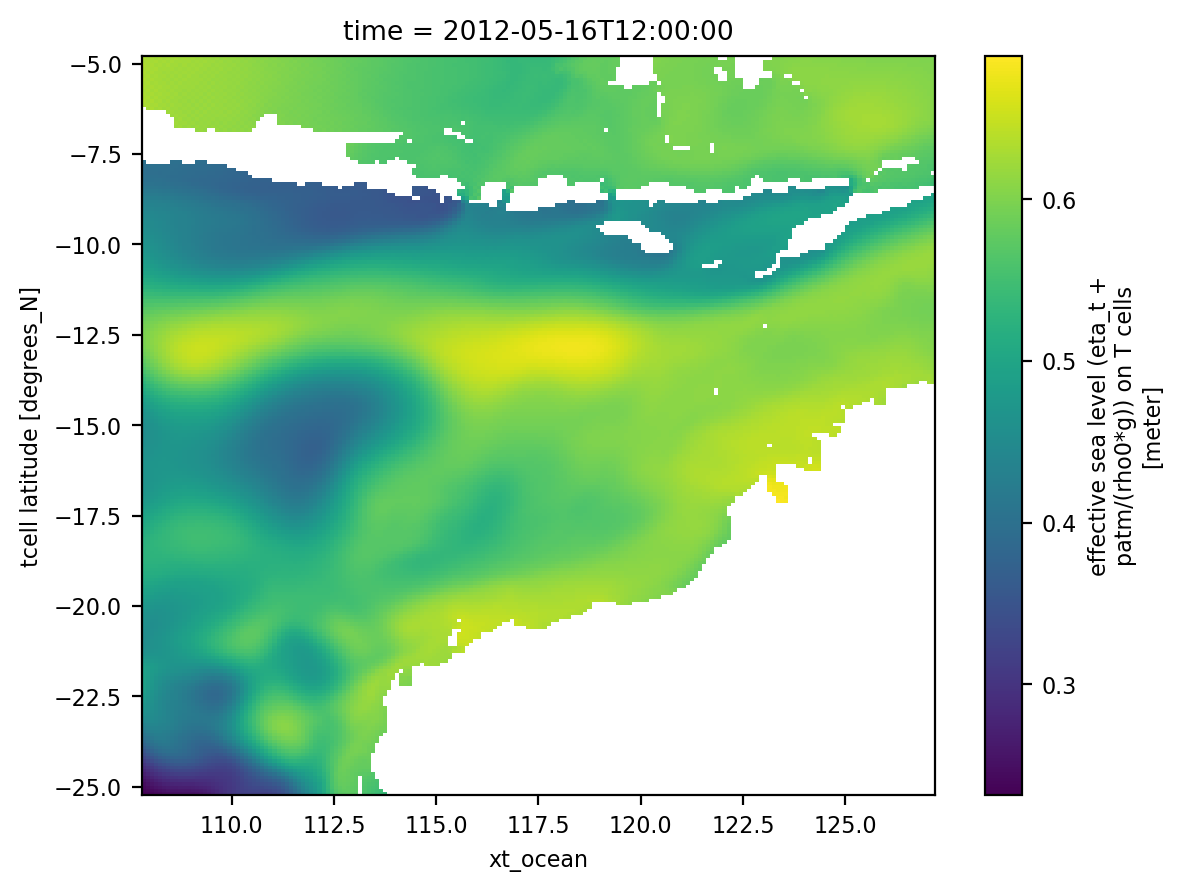

In [49]:
ic.sea_level.plot()

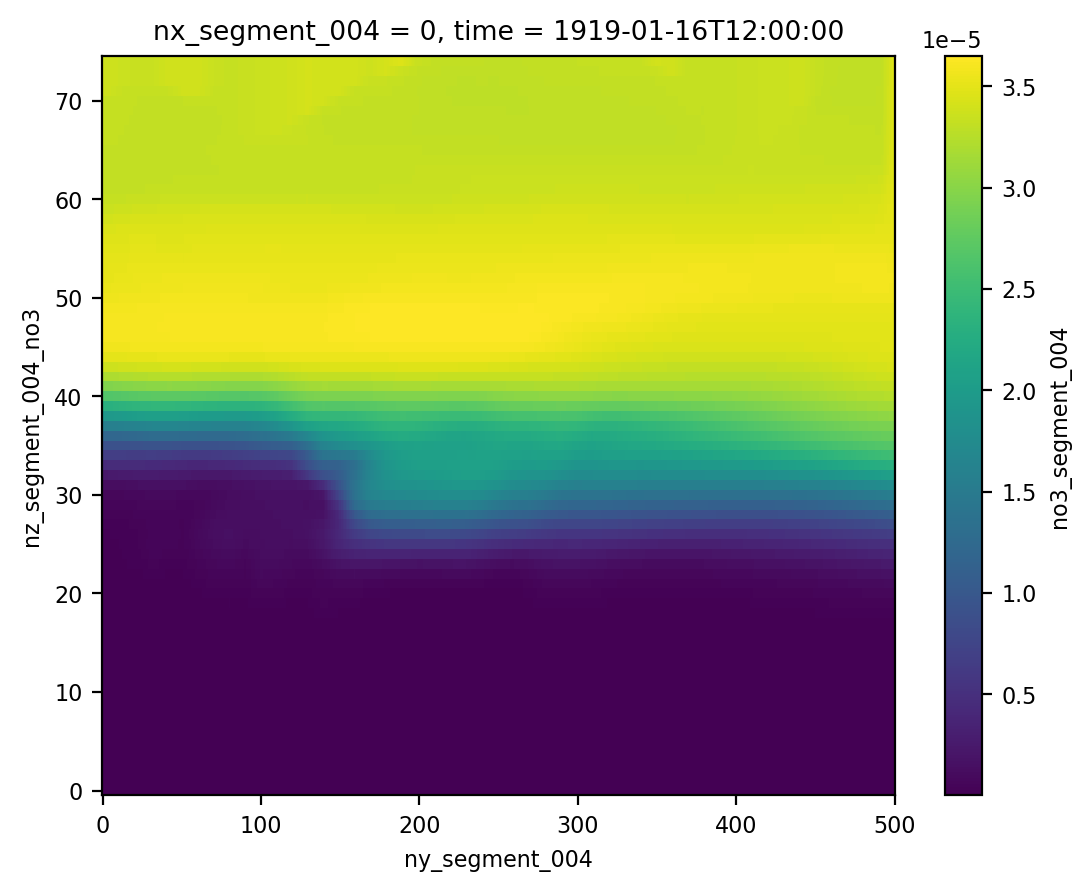

In [119]:
obcw=xr.open_dataset('/scratch/nm03/ee8016/regional_mom6_configs/NW_shelf_iaf_notides_wombatlite/obgc_obc.nc')
obcw.no3_segment_004.isel(time=0).plot()


In [4]:
obcw=xr.open_dataset('/scratch/nm03/ee8016/regional_mom6_configs/NW_shelf_iaf_notides_wombatlite_2/obgc_obc.nc')

In [6]:
obcw

<xarray.Dataset> Size: 450MB
Dimensions:                        (time: 12, nz_segment_001_u: 75,
                                    ny_segment_001: 1, nx_segment_001: 801,
                                    nz_segment_001_v: 75,
                                    nz_segment_001_salt: 75,
                                    nz_segment_001_temp: 75,
                                    nz_segment_001_no3: 75,
                                    ...
                                    nz_dicr_segment_004: 75,
                                    nz_dic_segment_004: 75,
                                    nz_detbury_segment_004: 75,
                                    nz_caco3bury_segment_004: 75,
                                    nz_detfe_sediment_segment_004: 75,
                                    nz_u_segment_004: 75, nz_v_segment_004: 75)
Coordinates: (12/114)
  * zl                             (zl) float64 600B 0.5413 1.681 ... 5.805e+03
    lon_segment_001                (nx_segment_001) float64 6kB ...
    lat_segment_001                (nx_segment_001) float64 6kB ...
  * nz_segment_001_salt            (nz_segment_001_salt) int32 300B 0 1 ... 74
  * nz_segment_001_temp            (nz_segment_001_temp) int32 300B 0 1 ... 74
  * nz_segment_001_no3             (nz_segment_001_no3) int32 300B 0 1 ... 73 74
    ...                             ...
  * nz_segment_004_detfe_sediment  (nz_segment_004_detfe_sediment) int32 300B ...
  * nz_segment_004_u               (nz_segment_004_u) int32 300B 0 1 2 ... 73 74
  * nz_segment_004_v               (nz_segment_004_v) int32 300B 0 1 2 ... 73 74
  * nx_segment_004                 (nx_segment_004) int32 4B 0
  * ny_segment_004                 (ny_segment_004) int32 2kB 0 1 2 ... 499 500
  * time                           (time) object 96B 1919-01-16 12:00:00 ... ...
Dimensions without coordinates: nz_salt_segment_001, nz_temp_segment_001,
                                nz_no3_segment_001, nz_fe_segment_001,
                                nz_o2_segment_001, nz_zoo_segment_001,
                                nz_phy_segment_001, nz_det_segment_001,
                                nz_caco3_segment_001, nz_alk_segment_001,
                                nz_caco3_sediment_segment_001,
                                ...
                                nz_zoofe_segment_004, nz_detfe_segment_004,
                                nz_dicp_segment_004, nz_dicr_segment_004,
                                nz_dic_segment_004, nz_detbury_segment_004,
                                nz_caco3bury_segment_004,
                                nz_detfe_sediment_segment_004,
                                nz_u_segment_004, nz_v_segment_004
Data variables: (12/204)
    u_segment_001                  (time, nz_segment_001_u, ny_segment_001, nx_segment_001) float32 3MB ...
    v_segment_001                  (time, nz_segment_001_v, ny_segment_001, nx_segment_001) float32 3MB ...
    eta_segment_001                (time, ny_segment_001, nx_segment_001) float32 38kB ...
    salt_segment_001               (time, nz_segment_001_salt, ny_segment_001, nx_segment_001) float32 3MB ...
    temp_segment_001               (time, nz_segment_001_temp, ny_segment_001, nx_segment_001) float32 3MB ...
    no3_segment_001                (time, nz_segment_001_no3, ny_segment_001, nx_segment_001) float32 3MB ...
    ...                             ...
    dz_caco3bury_segment_004       (time, nz_caco3bury_segment_004, ny_segment_004, nx_segment_004) float32 2MB ...
    dz_detfe_sediment_segment_004  (time, nz_detfe_sediment_segment_004, ny_segment_004, nx_segment_004) float32 2MB ...
    dz_u_segment_004               (time, nz_u_segment_004, ny_segment_004, nx_segment_004) float32 2MB ...
    dz_v_segment_004               (time, nz_v_segment_004, ny_segment_004, nx_segment_004) float32 2MB ...
    ny_segmnet_004                 (ny_segment_004) float32 2kB ...
    nx_segmnet_004                 float32 4B ...

In [ ]:
/scratch/nm03/ee8016/regional_mom6_configs/NW_shelf_iaf_notides_wombatlite_2/bathymetry.nc

In [7]:
ds = xr.open_dataset('/scratch/nm03/ee8016/regional_mom6_configs/NW_shelf_iaf_notides_wombatlite_2/bathymetry.nc')
#changing fillvalue
ds['depth'] = ds['depth'].fillna(0)
ds.to_netcdf('/scratch/nm03/ee8016/regional_mom6_configs/NW_shelf_iaf_notides_wombatlite_2/bathymetry_mod.nc')